# Local vertical alignment — Kakhovka reservoir gauges

**What this does.** For each gauge on the Kakhovka reservoir, take ICESat-2 ATL13
segments *near that post*, reduce them to EVRS via the EGG2015 quasigeoid, build a
**local** water-surface level per satellite pass, and match it to the post's stage
series. The residual is the **empirical vertical alignment constant**:

$$C = \mathrm{median}\left(H^{EVRS}_{ICESat} - \mathrm{stage}(t)\right)$$

so that $H_{gauge}^{aligned}(t) = \mathrm{stage}(t) + C$.

> ⚠️ **$C$ is not a Baltic-1977 → EVRS datum transformation.** It also absorbs the
> post's gauge-zero elevation and any systematic ICESat-2 / EGG2015 bias. Those are
> inseparable from ICESat + gauges alone.

**Why local and not reservoir-wide.** The reservoir-wide `pass_levels` table averages
ATL13 over ~130 km of pool. A tie at one post has to come from segments near that
post, so everything below starts from the **point-level** `kakhovka_atl13_evrs.parquet`.

**Calibration window.** `PRE_BREACH` only. After 2023-06-06 the local surface is no
longer the reservoir and must never enter the tie.

## 1 · Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from kakhovka_altimetry import viz
from kakhovka_altimetry.config import load_config
from kakhovka_altimetry.io import read_parquet
from kakhovka_altimetry.gauges import load_gauge_observations
from kakhovka_altimetry.local_alignment import (
    CALIBRATION_PERIOD, distance_to_station, local_pass_levels, match_local,
    radius_ladder, per_rgt, station_summary, reservoir_level_by_date,
)

cfg = load_config()
la = cfg.local_alignment
evrs = read_parquet(cfg.evrs_parquet)
reservoir = read_parquet(cfg.pass_levels_parquet)
obs = load_gauge_observations(cfg)
stations = [s for s in cfg.gauges.stations if s.complete]

print(f'{len(evrs):,} ATL13 segments | {len(reservoir):,} reservoir passes')
print(f'{len(stations)} gauges | main radius {la.main_radius_km} km, ladder {la.radii_km}, diagnostic {la.diagnostic_radius_km} km')

513,873 ATL13 segments | 1,680 reservoir passes
6 gauges | main radius 2.0 km, ladder (0.5, 1.0, 2.0, 3.0, 5.0), diagnostic 10.0 km


## 2 · Where the data is

The reservoir outline below is drawn **from the ATL13 water returns themselves** — they
*are* the observed water surface. Colour is the EVRS level; the pool sits near 16 m.

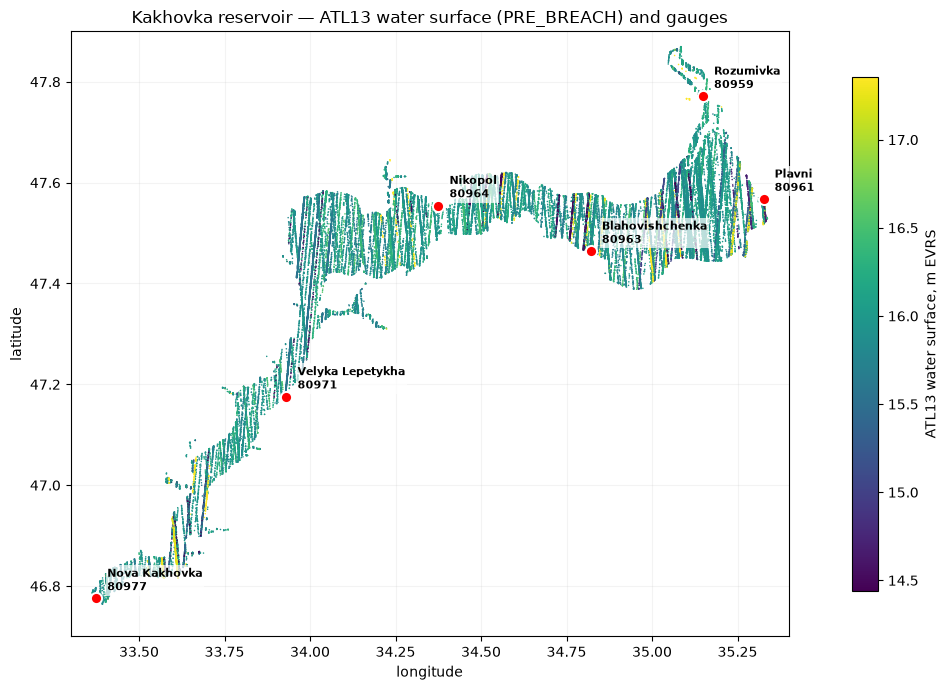

In [2]:
fig, ax = plt.subplots(figsize=(13, 7))
viz.overview_map(evrs, cfg, ax=ax)
fig.tight_layout()

ICESat-2 flies fixed ground tracks, so each post is crossed by only a handful of RGTs.
The rings are the radius ladder; colours are RGTs.

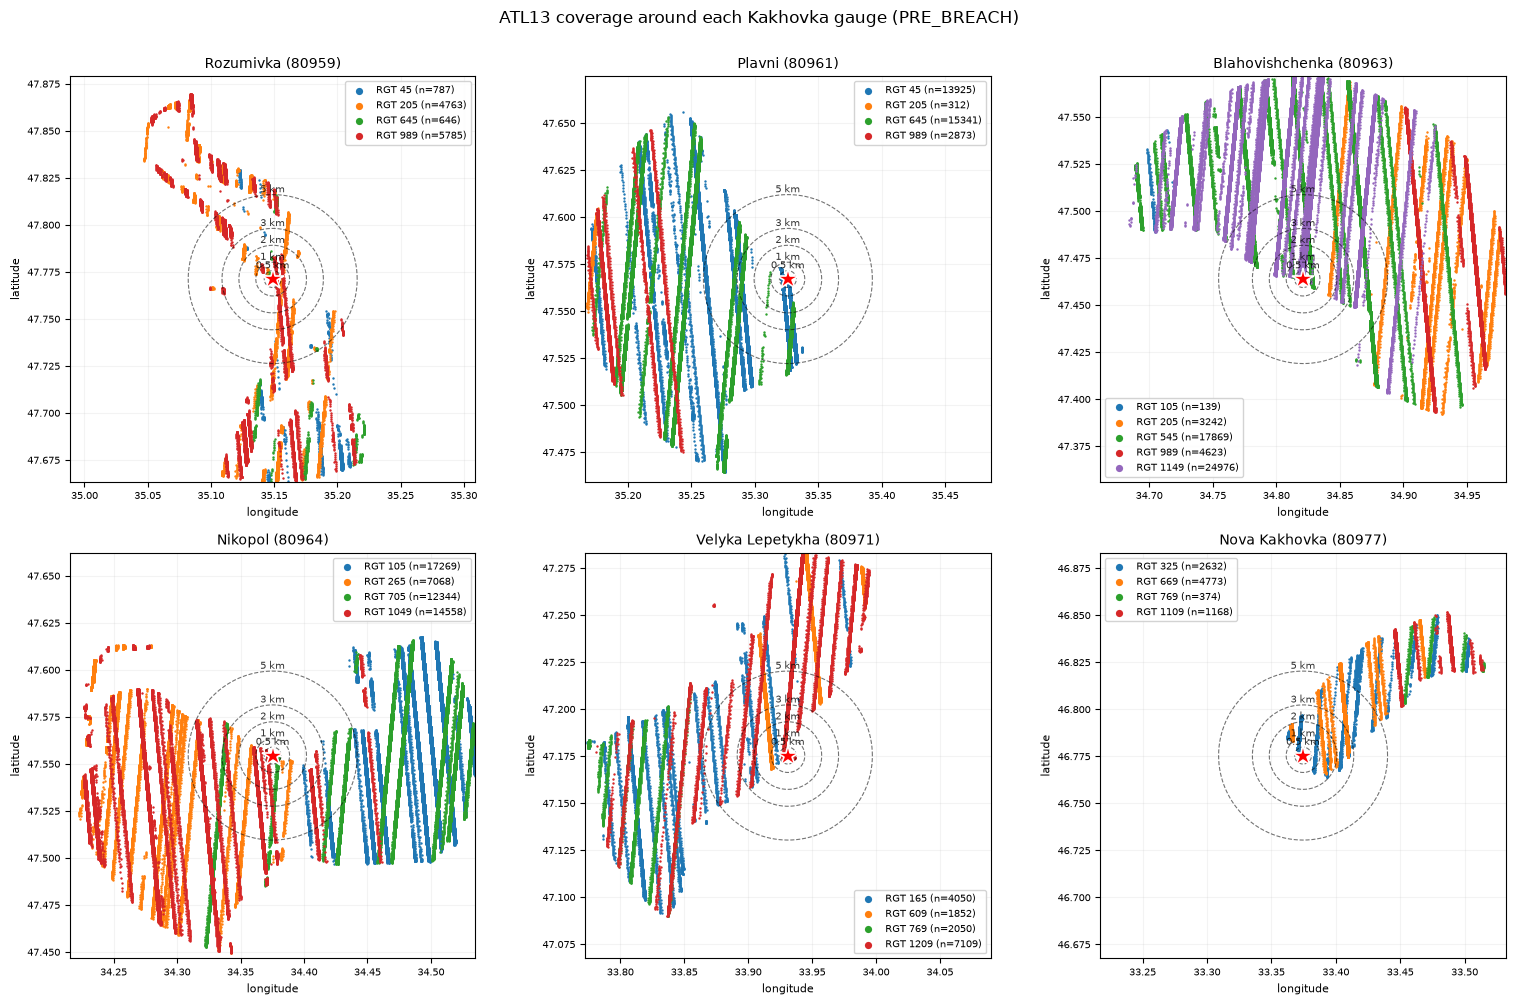

In [3]:
fig = viz.station_panel(evrs, cfg, view_km=12)

## 3 · The method, one station at a time

Walk through Розумівка explicitly, then loop over all posts.

In [4]:
st = cfg.gauges.station(la.station_id)
d = distance_to_station(evrs, st)
print(f'{st.name} ({st.id}) at {st.lat}, {st.lon}; nominal zero {st.gauge_zero_baltic_m} m BS-77')
for r in la.radii_km:
    sel = (d <= r) & (evrs['period'] == CALIBRATION_PERIOD).to_numpy(bool)
    print(f'  r <= {r:>4} km : {sel.sum():6d} ATL13 segments')

с. Розумівка (80959) at 47.771208, 35.14889; nominal zero 12.0 m BS-77
  r <=  0.5 km :     73 ATL13 segments
  r <=  1.0 km :    317 ATL13 segments
  r <=  2.0 km :    639 ATL13 segments
  r <=  3.0 km :   1183 ATL13 segments
  r <=  5.0 km :   2881 ATL13 segments


### 3.1 Local pass levels
Group the segments inside the radius by `(date, rgt, beam)` and take the **median**
`H_evrs_egg2015_m`. Local QC is deliberately *not* the reservoir-wide QC — track-length
and along-track-slope tests are reservoir-scale and meaningless in a 2 km circle.

In [5]:
level = reservoir_level_by_date(reservoir)   # ICESat-only reference level per date
lp = local_pass_levels(evrs, st, la.main_radius_km, cfg,
                       distance_km=d, reservoir_level=level)
lp[['date','rgt','beam','n_points','median_wse_evrs_m','nmad_m',
    'mean_distance_km','reservoir_level_m','deviation_from_reservoir_m',
    'local_qc_pass','local_qc_flags']]

,date,rgt,beam,n_points,median_wse_evrs_m,nmad_m,mean_distance_km,reservoir_level_m,deviation_from_reservoir_m,local_qc_pass,local_qc_flags
0,2019-07-11,205,gt2l,17,15.955307,0.021233,0.431100,15.999864,-0.044557,True,
1,2019-07-11,205,gt2r,5,16.062505,0.030896,0.564054,15.999864,0.062641,False,too_few_points
2,2019-08-09,645,gt3l,16,16.007157,0.018463,0.561876,16.017357,-0.010200,True,
3,2019-08-09,645,gt3r,4,16.029893,0.015124,0.688204,16.017357,0.012535,False,too_few_points
4,2020-02-29,989,gt3l,39,15.955105,0.021833,0.912580,15.947627,0.007478,True,
5,2020-02-29,989,gt3r,183,15.962439,0.016631,0.974921,15.947627,0.014812,True,
6,2020-04-08,205,gt1r,4,16.122131,0.012650,1.867962,16.120385,0.001746,False,too_few_points
7,2020-04-08,205,gt1l,1,17.094217,0.000000,1.878707,16.120385,0.973832,False,too_few_points
8,2020-10-07,205,gt1l,36,15.853237,0.040272,1.181945,15.859345,-0.006108,True,
9,2020-10-07,205,gt1r,8,15.870526,0.014100,1.343282,15.859345,0.011181,False,too_few_points


The third QC test is a **plausibility gate**: the local level must sit within
`max_deviation_from_reservoir_m` of the reservoir-wide ICESat level *on the same date*.
It catches internally-flat **bank/land** returns that the NMAD test cannot see — a flat
surface 7 m above the water passes an NMAD test but is obviously not the reservoir.
The reference is ICESat-only; the gauge plays no part, so there is no circularity.

In [6]:
wide = local_pass_levels(evrs, st, 3.0, cfg, distance_km=d, reservoir_level=level)
rejected = wide[~wide['local_qc_pass']]
rejected[['date','rgt','beam','n_points','median_wse_evrs_m','nmad_m',
          'reservoir_level_m','deviation_from_reservoir_m','local_qc_flags']]

,date,rgt,beam,n_points,median_wse_evrs_m,nmad_m,reservoir_level_m,deviation_from_reservoir_m,local_qc_flags
1,2019-07-11,205,gt2r,5,16.062505,0.030896,15.999864,0.062641,too_few_points
3,2019-08-09,645,gt3r,4,16.029893,0.015124,16.017357,0.012535,too_few_points
4,2019-09-29,45,gt1l,4,15.626074,0.032660,15.772905,-0.146831,too_few_points
5,2019-09-29,45,gt1r,9,15.691994,0.012762,15.772905,-0.080911,too_few_points
8,2020-02-29,989,gt2r,21,22.985101,0.037104,15.947627,7.037474,implausible_level
12,2020-04-08,205,gt1l,1,17.094217,0.000000,16.120385,0.973832,too_few_points
14,2020-10-07,205,gt1r,8,15.870526,0.014100,15.859345,0.011181,too_few_points
15,2021-02-26,989,gt2l,8,16.169583,0.008062,16.116467,0.053117,too_few_points
21,2022-03-26,45,gt1l,6,30.229521,0.646595,16.123199,14.106321,too_few_points|nmad_too_large|implausible_level
22,2022-03-26,45,gt1r,1,16.099370,0.000000,16.123199,-0.023830,too_few_points


### 3.2 Match to the gauge and form the residual

In [7]:
m = match_local(lp, obs[obs.station_id == st.id], st, cfg)
m[['date','rgt','beam','n_points','median_wse_evrs_m','stage_m',
   'alignment_constant_m','evrs_minus_bs77_m','time_difference_hours']]

,date,rgt,beam,n_points,median_wse_evrs_m,stage_m,alignment_constant_m,evrs_minus_bs77_m,time_difference_hours
0,2020-02-29,989,gt3l,39,15.955105,3.630654,12.324451,0.324451,4.934593
1,2020-02-29,989,gt3r,183,15.962439,3.630655,12.331784,0.331784,4.934501
2,2020-10-07,205,gt1l,36,15.853237,3.576171,12.277066,0.277066,2.199641
3,2021-02-26,989,gt2r,37,16.191274,3.841434,12.349840,0.349840,1.720720
4,2021-04-07,205,gt2l,39,16.337123,3.841303,12.495820,0.495820,1.130264
5,2021-04-07,205,gt2r,118,16.332781,3.841304,12.491478,0.491478,1.130356
6,2021-11-26,989,gt2l,82,16.116629,3.811649,12.304980,0.304980,0.715783
7,2021-11-26,989,gt2r,29,16.166597,3.811648,12.354949,0.354949,0.715884
8,2022-07-05,205,gt1r,10,16.363223,4.003198,12.360024,0.360024,3.455872


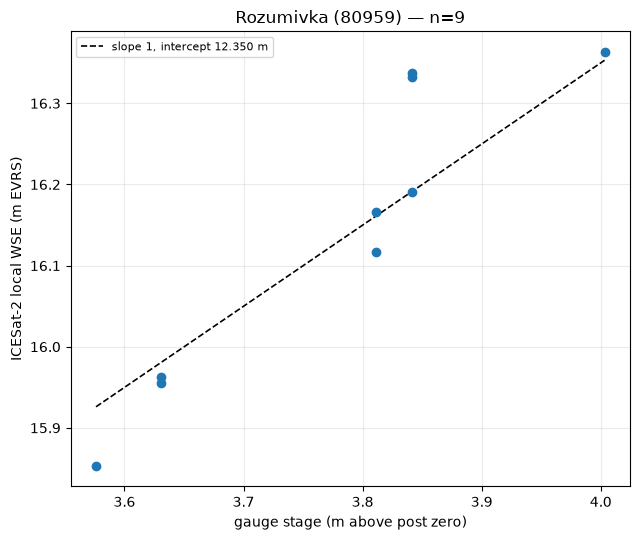

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
viz.gauge_vs_icesat(m, st, ax=ax)
fig.tight_layout()

Slope is fixed at 1 by construction — we are estimating an **offset**, not a
regression. The intercept is the alignment constant.

## 4 · Sensitivity to the radius

A tight radius minimises any water-surface gradient but starves the sample; a wide one
does the opposite. If the constant is stable across the ladder, the tie is real and not
an artefact of the radius choice.

In [9]:
ladders, matchups_all, summaries = {}, {}, []
all_radii = tuple(sorted({*la.radii_km, la.main_radius_km, la.diagnostic_radius_km}))
for s in stations:
    o = obs[obs.station_id == s.id]
    ladder, mm = radius_ladder(evrs, o, s, cfg, radii=all_radii,
                               reservoir_passes=reservoir)
    ladders[s.name_en] = ladder
    matchups_all[s.id] = mm
    summaries.append(station_summary(s, ladder, cfg))
summary = pd.DataFrame(summaries).sort_values('distance_from_dam_km').reset_index(drop=True)
ladders[st.name_en].round(4)

,radius_km,n_matchups,n_dates,n_rgts,rgts,alignment_constant_m,nmad_m,std_m,ci95_low_m,ci95_high_m,evrs_minus_bs77_m,indicative
0,0.5,1,1,1,989,12.3356,0.0000,NaN,NaN,NaN,0.3356,True
1,1.0,7,4,2,"205,989",12.3467,0.0318,0.0802,12.3172,12.3762,0.3467,False
2,2.0,9,6,2,"205,989",12.3498,0.0376,0.0771,12.3190,12.3807,0.3498,False
3,3.0,15,7,2,"205,989",12.3498,0.0673,0.0677,12.3072,12.3925,0.3498,False
4,5.0,29,10,3,"45,205,989",12.3585,0.0511,0.0832,12.3352,12.3818,0.3585,False
5,10.0,54,15,4,"45,205,645,989",12.3424,0.0670,0.1260,12.3200,12.3648,0.3424,False


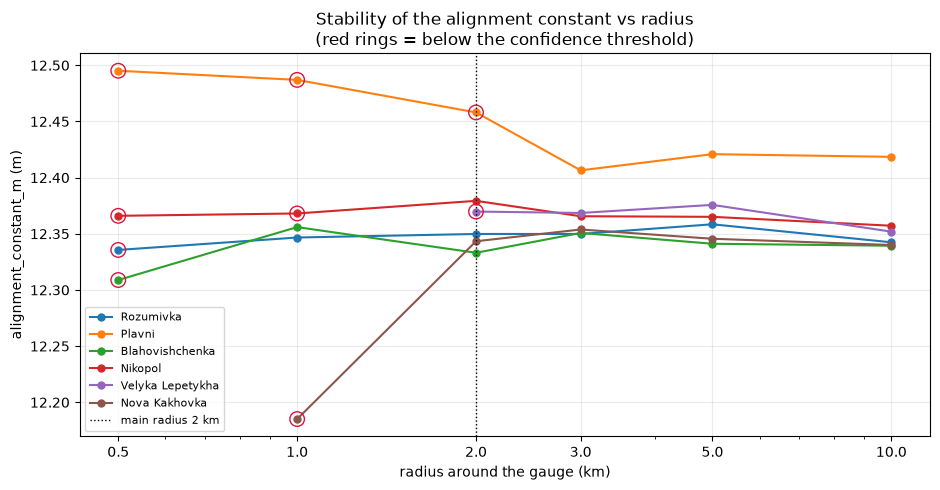

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5))
viz.radius_stability(ladders, cfg, ax=ax)
fig.tight_layout()

Red rings mark radii below the confidence threshold (`min_matchups_for_confidence`). Where a post's main radius is too thin, the
reported value falls back to the smallest radius that does reach it — recorded in
the `note` column of the summary.

## 5 · All posts

In [11]:
cols = ['station_id','name_en','distance_from_dam_km','reported_radius_km',
        'n_reported','alignment_constant_m','nmad_m','ci95_low_m','ci95_high_m',
        'evrs_minus_bs77_m','note']
summary[cols].round(3)

,station_id,name_en,distance_from_dam_km,reported_radius_km,n_reported,alignment_constant_m,nmad_m,ci95_low_m,ci95_high_m,evrs_minus_bs77_m,note
0,80977,Nova Kakhovka,0.000,2.0,12,12.343,0.053,12.306,12.381,0.343,
1,80971,Velyka Lepetykha,61.317,3.0,5,12.369,0.060,12.303,12.435,0.369,main radius too thin (n=2); reported at 3 km
2,80964,Nikopol,115.009,2.0,8,12.379,0.034,12.350,12.409,0.379,
3,80963,Blahovishchenka,133.556,2.0,11,12.333,0.049,12.296,12.370,0.333,
4,80961,Plavni,171.775,3.0,8,12.406,0.060,12.354,12.459,0.406,main radius too thin (n=2); reported at 3 km
5,80959,Rozumivka,173.713,2.0,9,12.350,0.038,12.319,12.381,0.350,


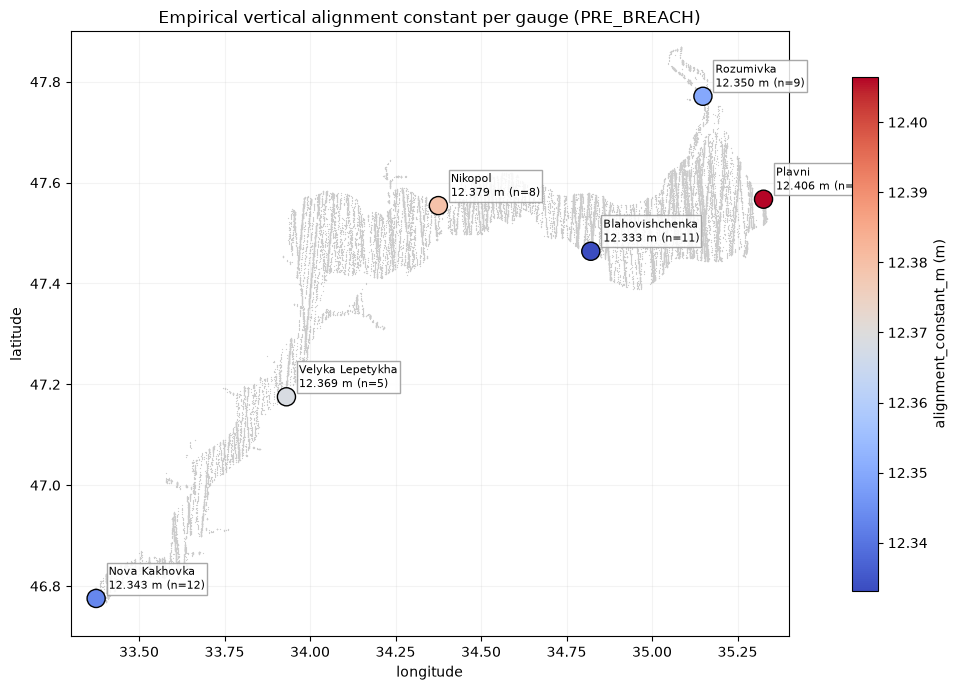

In [12]:
fig, ax = plt.subplots(figsize=(13, 7))
viz.alignment_map(summary, evrs, cfg, ax=ax)
fig.tight_layout()

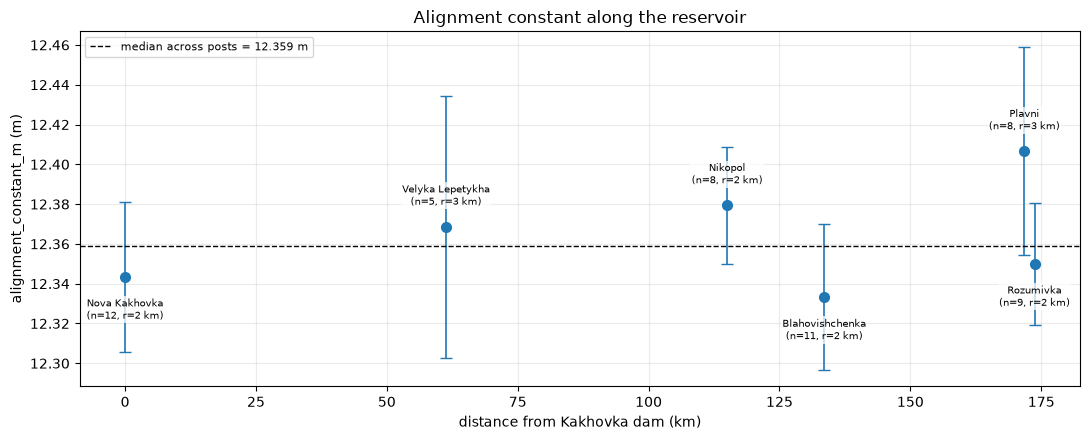

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
viz.longitudinal_profile(summary, ax=ax)
fig.tight_layout()

### 5.1 What the spread means

Every post carries the **same nominal 12.00 m BS-77 zero** (the reservoir-wide figure
from the donor report — no surveyed per-post zeros exist), and the donor's own boundary
analysis puts the pool's surface slope at ~10⁻⁵, i.e. **< 0.2 m over the whole 178 km**.

So the spread between posts is **not** a water-surface gradient: it is essentially the
**relative error between the posts' true gauge zeros**. Supply one surveyed zero and
every other post's zero follows from its own constant.

In [14]:
ok = summary[summary.alignment_constant_m.notna()]
print(f'posts with a tie : {len(ok)}')
print(f'median C         : {ok.alignment_constant_m.median():.3f} m')
print(f'spread           : {(ok.alignment_constant_m.max()-ok.alignment_constant_m.min())*100:.1f} cm')
print(f'median NMAD      : {ok.nmad_m.median():.3f} m')
corr = ok[['distance_from_dam_km','alignment_constant_m']].corr().iloc[0,1]
print(f'corr(C, distance from dam) = {corr:+.2f}  '
      f'-> {"no" if abs(corr) < 0.5 else "possible"} longitudinal trend')

posts with a tie : 6
median C         : 12.359 m
spread           : 7.3 cm
median NMAD      : 0.051 m
corr(C, distance from dam) = +0.34  -> no longitudinal trend


## 6 · Per-RGT bias

Does one ground track sit systematically high or low? Computed at the main radius and
again at the diagnostic radius, where each RGT has enough matchups to mean something.

In [15]:
rgt_tables = []
for s in stations:
    mm = matchups_all[s.id]
    if mm.empty:
        continue
    for r in (la.main_radius_km, la.diagnostic_radius_km):
        t = per_rgt(mm, r)
        if not t.empty:
            rgt_tables.append(t.assign(station=s.name_en))
rgt_all = pd.concat(rgt_tables, ignore_index=True)
diag = rgt_all[(rgt_all.radius_km == la.diagnostic_radius_km) & (rgt_all.rgt != 'ALL')]
diag.sort_values('bias_relative_to_pooled_m').round(4)

,rgt,radius_km,n_matchups,icesat_median_wse_m,gauge_median_stage_m,alignment_constant_m,nmad_m,bias_relative_to_pooled_m,station
5,645,10.0,1,15.2657,3.2382,12.0275,0.0000,-0.3149,Rozumivka
3,45,10.0,4,16.1148,3.8835,12.2469,0.0992,-0.0956,Rozumivka
18,205,10.0,4,15.8543,3.5541,12.2986,0.0241,-0.0407,Blahovishchenka
11,645,10.0,10,15.9973,3.6188,12.3950,0.0438,-0.0234,Plavni
21,1149,10.0,28,15.8988,3.5911,12.3251,0.0366,-0.0143,Blahovishchenka
34,165,10.0,16,15.9625,3.6008,12.3396,0.0225,-0.0123,Velyka Lepetykha
6,989,10.0,23,16.1015,3.8117,12.3311,0.0479,-0.0113,Rozumivka
43,769,10.0,2,15.9291,3.5975,12.3317,0.0634,-0.0083,Nova Kakhovka
28,705,10.0,7,16.0325,3.6095,12.3489,0.0130,-0.0083,Nikopol
44,1109,10.0,1,16.3238,3.9884,12.3354,0.0000,-0.0046,Nova Kakhovka


In [16]:
well = diag[diag.n_matchups >= la.min_matchups_for_confidence]
print(f'RGTs with n >= {la.min_matchups_for_confidence}: {len(well)} of {len(diag)}')
print(f'bias range among those: {well.bias_relative_to_pooled_m.min():+.3f} .. '
      f'{well.bias_relative_to_pooled_m.max():+.3f} m')
thin = diag[diag.n_matchups < la.min_matchups_for_confidence]
if len(thin):
    print('\nToo thin to interpret:')
    print(thin[['station','rgt','n_matchups','bias_relative_to_pooled_m']].to_string(index=False))

RGTs with n >= 5: 14 of 23
bias range among those: -0.023 .. +0.040 m

Too thin to interpret:
         station  rgt  n_matchups  bias_relative_to_pooled_m
       Rozumivka   45           4                  -0.095564
       Rozumivka  645           1                  -0.314903
          Plavni  989           4                   0.014674
 Blahovishchenka  105           2                   0.024954
 Blahovishchenka  205           4                  -0.040747
 Blahovishchenka  989           2                   0.005356
Velyka Lepetykha  769           2                   0.108887
   Nova Kakhovka  769           2                  -0.008349
   Nova Kakhovka 1109           1                  -0.004628


## 7 · Residuals over time

If the tie is a genuine constant, the residuals should be flat in time with no drift.

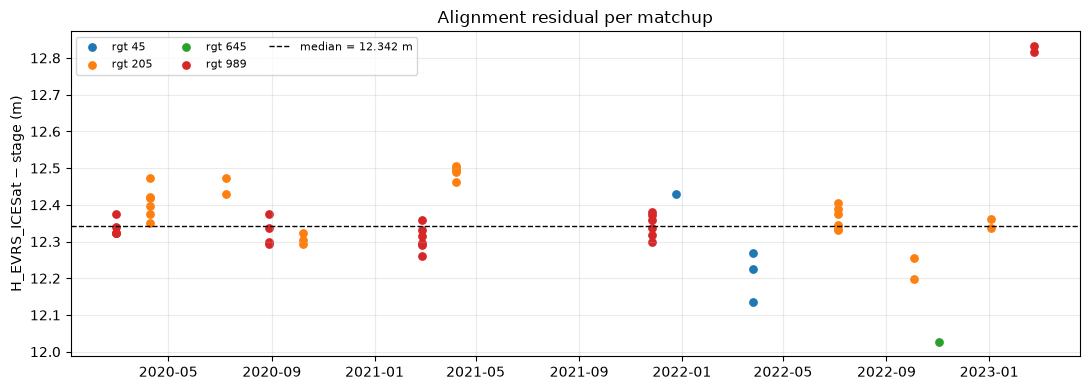

In [17]:
mm = matchups_all[st.id]
mm = mm[np.isclose(mm.radius_km, la.diagnostic_radius_km)]
fig, ax = plt.subplots(figsize=(11, 4))
viz.residual_timeseries(mm, ax=ax)
fig.tight_layout()

## 8 · Summary

1. Every Kakhovka post gets a local vertical tie to ICESat-2/EGG2015, from ATL13
   segments near that post, `PRE_BREACH` only.
2. The constant is stable across the radius ladder and shows **no trend along the
   reservoir** — consistent with a quasi-horizontal pool.
3. The spread between posts is the **relative gauge-zero error**, not a hydraulic
   gradient, because all posts share one nominal 12.00 m zero.
4. $C$ remains an **empirical vertical alignment constant**. Turning any part of it
   into a Baltic→EVRS datum offset needs one external constraint: a surveyed BS-77
   gauge zero, a GNSS height on a benchmark, or an official transformation.
   `datum.solve_geodetic_datum_offset()` is a deliberate stub until then.

Reproduce everything outside the notebook with:

```bash
python scripts/local_alignment.py --maps
```